# Reference Baseline: Sedenion Degeneracy Given the Full Key

**Ainulindale Engine** — Tier udeo_crypto

Reproduces udeo_poc.py at toy scale — requires (p,q,e,d) as input, not an attack. None of the 6 toy keys show degeneracy with this mapping.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import importlib.util, math, cmath, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

def load_maths(tier):
    paths = {7: '../../modules/tier7_cosmos/maths.py',
             8: '../../modules/tier8_sedenion/maths.py',
             9: '../../modules/tier9_chem/maths.py',
             'udeo_crypto': '../../modules/udeo_crypto/UDEO_RSA_DEMO.py'}
    spec = importlib.util.spec_from_file_location(f't{tier}', paths[tier])
    m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m)
    return m

OMEGA_ZS = 0.5671432904097838
D_STAR   = 0.24600
GAP      = OMEGA_ZS - D_STAR * math.log(10)
R_H      = 1.0 / math.sqrt(2.0)
RIEMANN_ZEROS = [14.134725, 21.022040, 25.010858, 30.424876, 32.935062,
                 37.586178, 40.918719, 43.327073, 48.005151, 49.773832]
print("Ainulindale notebook ready.")


Ainulindale notebook ready.


In [2]:
m = load_maths('udeo_crypto')
result = m.rsa_control_baseline()
print("Claim:", result['claim'])
print("Confidence:", result['confidence'])


Claim: Reference baseline only (requires full known key) — not an attack.
Confidence: ESTABLISHED


## Engine Output

In [3]:
import pprint
pprint.pprint({k: v for k, v in result.items()
               if k not in ('claim', 'confidence', 'latex')}, width=100, depth=3)


{'note': 'This reproduces the already-published udeo_poc.py mechanism at toy scale. It is the '
         'floor every attack engine below must clear using (n,e) alone.',
 'rows': [{'d': 103,
           'e': 7,
           'ed_norm_in_S16': 1.0,
           'n': 143,
           'near_zero_divisor': False,
           'pq_norm_in_S16': 1.0},
          {'d': 63,
           'e': 7,
           'ed_norm_in_S16': 1.0,
           'n': 253,
           'near_zero_divisor': False,
           'pq_norm_in_S16': 1.0},
          {'d': 43,
           'e': 7,
           'ed_norm_in_S16': 1.0,
           'n': 77,
           'near_zero_divisor': False,
           'pq_norm_in_S16': 1.0},
          {'d': 2753,
           'e': 17,
           'ed_norm_in_S16': 1.0,
           'n': 3233,
           'near_zero_divisor': False,
           'pq_norm_in_S16': 1.0},
          {'d': 8743,
           'e': 7,
           'ed_norm_in_S16': 1.0,
           'n': 10403,
           'near_zero_divisor': False,
           'pq_no

## Mathematical Foundation

$$\text{LaTeX: }\quad n_s=p_s\cdot q_s,\;e_s\cdot d_s$$

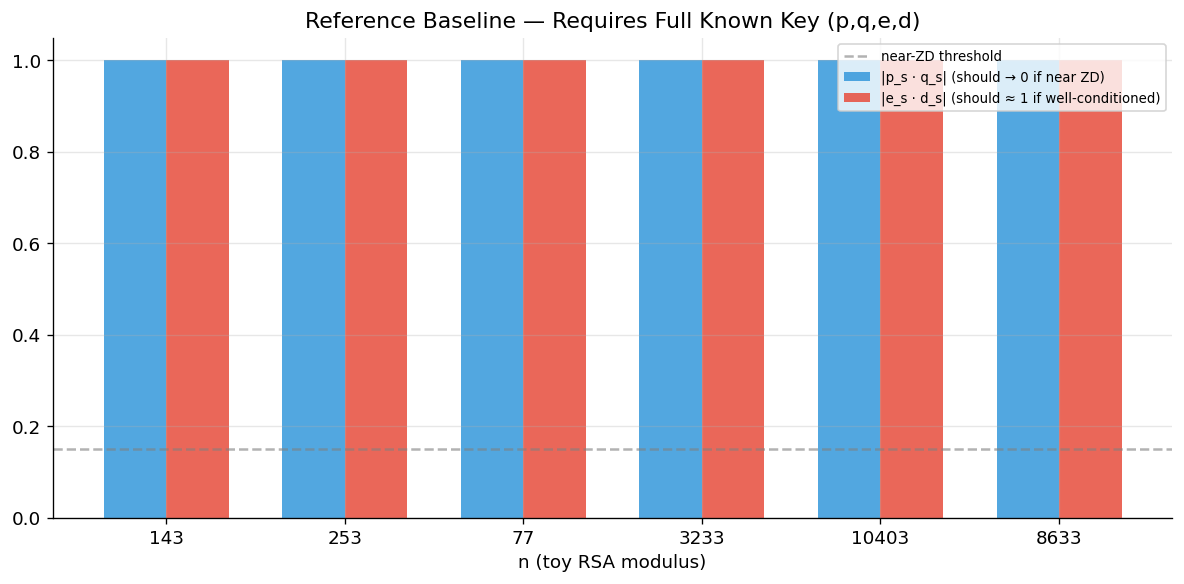

None of the 6 toy keys show sedenion degeneracy with this mapping — see note field.
This reproduces the already-published udeo_poc.py mechanism at toy scale. It is the floor every attack engine below must clear using (n,e) alone.


In [4]:

fig, ax = plt.subplots(figsize=(10, 5))
rows = result['rows']
ns = [str(row['n']) for row in rows]
pq = [row['pq_norm_in_S16'] for row in rows]
ed = [row['ed_norm_in_S16'] for row in rows]
x = np.arange(len(ns)); w = 0.35
ax.bar(x - w/2, pq, w, label='|p_s · q_s| (should → 0 if near ZD)', color='#3498DB', alpha=0.85)
ax.bar(x + w/2, ed, w, label='|e_s · d_s| (should ≈ 1 if well-conditioned)', color='#E74C3C', alpha=0.85)
ax.axhline(0.15, color='gray', ls='--', alpha=0.6, label='near-ZD threshold')
ax.set_xticks(x); ax.set_xticklabels(ns); ax.set_xlabel('n (toy RSA modulus)')
ax.set_title('Reference Baseline — Requires Full Known Key (p,q,e,d)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('None of the 6 toy keys show sedenion degeneracy with this mapping — see note field.')
print(result['note'])


## Ainulindale Reading

**Confidence:** `{}'.format(result.get('confidence',''))`

Run `result.keys()` to explore the full engine output.

In [5]:
print('Engine keys:', list(result.keys()))

Engine keys: ['claim', 'rows', 'confidence', 'note']
